# Melt energy partitioning

**`∆Q = Rn + H + L + G + M (Eq. 1)`**  
We will partition available melt energy by flux terms (Eq. 1) to investigate and quantify current driving fluxes within each watershed.
- Lwnet/∆Q
- SWnet/∆Q
- LH/∆Q
- H/∆Q
- L/∆Q
- M/∆Q


Per-pixel daily values will be computed
--> Store ∆Q (for back-computation), and then per-pixel fractions for each flux term into a new netcdf, these will need to be daily?

In [1]:
import sys
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import pyproj


sys.path.append('/uufs/chpc.utah.edu/common/home/u6058223/git_dirs/env/')
import helpers as h

sys.path.append('/uufs/chpc.utah.edu/common/home/u6058223/git_dirs/ucrb-isnobal/scripts/')
import processing as proc

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
from pathlib import PurePath
# Locate pyproj_datadir for studio env
# From https://stackoverflow.com/questions/69630630/on-fresh-conda-installation-of-pyproj-pyproj-unable-to-set-database-path-pypr
CONDA_ENV = 'studio'
miniconda_dir = '/uufs/chpc.utah.edu/common/home/u6058223/software/pkg/miniconda3'
proj_version = h.fn_list(miniconda_dir, f'envs/{CONDA_ENV}/conda-meta/proj-[0-9]*.json')[0]

VERSION = PurePath(proj_version).stem
pyprojdatadir = f'{miniconda_dir}/pkgs/{VERSION}/share/proj'
print(pyprojdatadir)
pyproj.datadir.set_data_dir(pyprojdatadir)

/uufs/chpc.utah.edu/common/home/u6058223/software/pkg/miniconda3/pkgs/proj-9.4.1-h54d7996_1/share/proj


## Set up files and directories

In [4]:
workdir = '/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp'
script_dir = '/uufs/chpc.utah.edu/common/home/skiles-group3/jmhu/isnobal_scripts'

In [5]:
# Basin-specific variables
# TODO: amend this to handle multiple WYs

basin = 'animas' # Specify basin
WY = 2022 # Specify WY

# Locate basindirs - run iSnobal+HRRR (original "Baseline") and Unified
# basindirs = h.fn_list(workdir, f'{basin}*isnobal/wy{WY}/{basin}*/')
# Locate basindirs - just the THP runs for now, can symlink the Baseline, HRRR-SPIReS, and Unified (no veg) runs later
# basindirs = h.fn_list(workdir, f'{basin}*/wy{WY}/{basin}*/')
# _ = [print(b) for b in basindirs]

# Locate wydirs that contain the extracted csvs
wy_dirs = h.fn_list(workdir, f'{basin}*/wy{WY}/')
print(wy_dirs)

['/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/']


### Read in the em files

In [6]:
# Instead of the netcdf route,  use extract_isnobal_timeseries_point.py to extract csvs
# then read those csvs in
em_csvs = [h.fn_list(wy_dir, f'*_em_*.csv') for wy_dir in wy_dirs]

# Flatten this single water year's csv files into a single list
em_csvs = h.flatten(em_csvs)
em_csvs

['/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_em_SWI_snotelmetloom_wy2022.csv',
 '/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_em_cold_content_snotelmetloom_wy2022.csv',
 '/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_em_evaporation_snotelmetloom_wy2022.csv',
 '/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_em_latent_heat_snotelmetloom_wy2022.csv',
 '/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_em_net_rad_snotelmetloom_wy2022.csv',
 '/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_em_precip_advected_snotelmetloom_wy2022.csv',
 '/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/

In [7]:
def extract_varname(csv_fn):
    # Pull the variable name from the filenames
    return csv_fn.split('_em_')[1].split('_snotel')[0]

In [8]:
# Use the variable name as a key to store the dataframes in a dictionary
for f in em_csvs:
    extract_varname(f)
# This enables easy plotting by variable across sites
em_df_dict = {extract_varname(em_csv): pd.read_csv(em_csv, index_col=0, parse_dates=True) for em_csv in em_csvs}
em_df_dict.keys()

dict_keys(['SWI', 'cold_content', 'evaporation', 'latent_heat', 'net_rad', 'precip_advected', 'sensible_heat', 'snow_soil', 'snowmelt', 'sum_EB'])

In [9]:
# Construct a multi-index df by concatenating the dfs in the dict by date index
em_df = pd.concat(em_df_dict, axis=1)                # gives columns (variable, site)

# Swap the levels of the column index to get (site, variable) and sort by site
em_df = em_df.swaplevel(0, 1, axis=1).sort_index(axis=1)

# Drop all of the 00:00 rows
em_df = em_df[em_df.index.time != pd.to_datetime('00:00').time()]

# See all of the top level column labels (sites)
print(em_df.columns.get_level_values(0).unique())

# See all of the second level column labels (variables)
print(em_df.columns.get_level_values(1).unique())

Index(['Cascade #2 (387)', 'Mineral Creek (629)', 'Molas Lake (632)',
       'Red Mountain Pass (713)', 'Spud Mountain (780)'],
      dtype='object')
Index(['SWI', 'cold_content', 'evaporation', 'latent_heat', 'net_rad',
       'precip_advected', 'sensible_heat', 'snow_soil', 'snowmelt', 'sum_EB'],
      dtype='object')


### Check out a single site

In [10]:
# Pull out one site to test things out
this_site = em_df.columns.get_level_values(0).unique()[0]
sub_df = em_df[this_site].copy()

### Plot the weekly average to get a seasonal overview

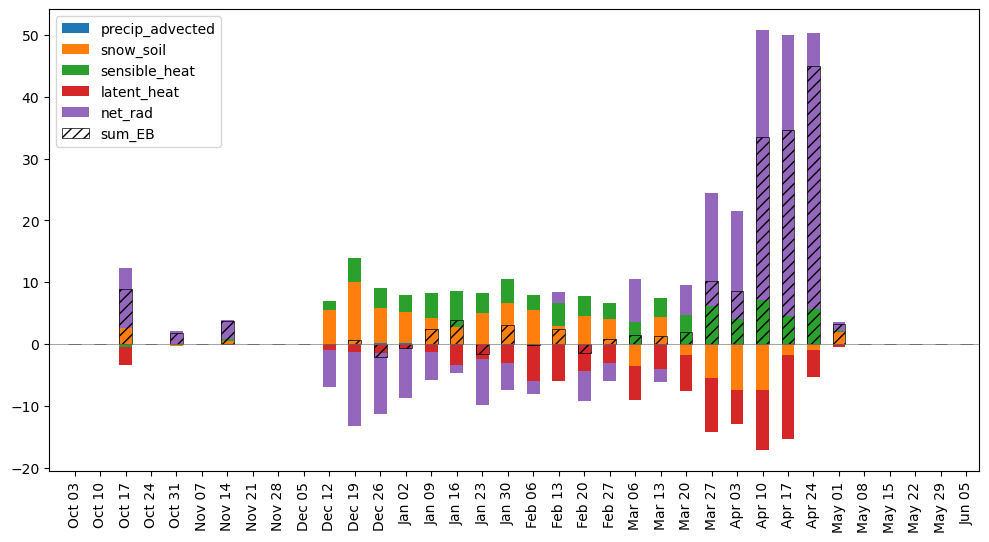

In [11]:
# Ok, now let's plot this with weekly averages
weekly_avg = sub_df.resample('W').mean()

# Plot this buddy as a stacked bar plot
ax = weekly_avg.plot(y=['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_rad'],
                kind='bar', stacked=True, figsize=(12, 6), legend=False)
# Plot sum_EB as a line on top of the stacked bar plot as a hatch-filled bar
weekly_avg.plot(y='sum_EB', kind='bar', ax=ax, hatch='///', color='none', edgecolor='black', linewidth=0.5, label='sum_EB', legend=True)
# Compute sum of positive energy fluxes
weekly_avg[['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_rad']].clip(lower=0).sum(axis=1)

ax.axhline(0, color='grey', linewidth=0.5, linestyle='-')
# Format xtick labels to show month and day
xticks = weekly_avg.index
# Mon abbreviation and day number
xtick_labels = [xtick.strftime('%b %d') for xtick in xticks]
ax.set_xticks(ticks=range(len(xticks)), labels=xtick_labels)
# Shorten the xlims to the most interesting part of the season, Oct to June, in week numbers
week_end = 35
ax.set_xlim(-1, week_end + 0.5)
plt.legend()

In [12]:
# # Convert all values to absolute values and re-plot the stacked bar plot
# abs_df = sub_df[['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_rad']].abs()
# abs_df_weekly = abs_df.resample('W').mean()

# # Compute sum of the absolute values of the energy fluxes and compute the percentage contribution of each flux to the total absolute energy flux
# abs_df_weekly['total_abs_flux'] = abs_df_weekly.sum(axis=1)
# for col in ['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_rad']:
#     abs_df_weekly[f'{col}_pct'] = abs_df_weekly[col] / abs_df_weekly['total_abs_flux'] * 100

In [13]:
# # Convert all values to absolute values and re-plot the stacked bar plot
# flux_cols = ['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_rad']
# ax = abs_df_weekly.plot(y=flux_cols, kind='bar', stacked=True, figsize=(12, 6), legend=False)

# # Annotate each stacked segment with its percent contribution
# for bar_idx, dt in enumerate(abs_df_weekly.index):
#     row_vals = abs_df_weekly.loc[dt]
#     row_cumulativesum = row_vals[flux_cols].cumsum()

#     for col in flux_cols:
#         value = row_vals[col]
#         pct = row_vals[f'{col}_pct']

#         # Only annotate segments large enough to read
#         if value > 5:
#             xloc = bar_idx
#             yloc = row_cumulativesum[col] - value / 2.0
#             ax.text(xloc, yloc, f'{pct:.0f}%',
#                     ha='center', va='center',
#                     fontsize=8, rotation=90,
#                     fontweight='bold', color='white')

# # Format xtick labels to show month and day
# ax.set_xticks(ticks=range(len(abs_df_weekly.index)), labels=abs_df_weekly.index.strftime('%b %d'))
# # Shorten the xlims to the most interesting part of the season, Oct to May, in week numbers
# ax.set_xlim(-1, week_end)
# plt.legend()

### Break net radiation in net solar and net longwave components
We output both the net_solar and the thermal.nc files for each day's model run.  
net_solar is net_SW but thermal.nc is LW_in.  
We can just use net_rad to get net_LW like so -  
`R_n = S_n + (SNOW_EMISSIVITY * (I_lw - STEF_BOLTZ * pow(T_s_0, 4)))`  
which is equivalent to:  
`R_n = S_n + L_n`

In [14]:
# Read in newly extracted csvs, dropping all the em ones and the snow depth one
csvs = h.fn_list(wy_dirs[0], '*csv')
csvs = [csv for csv in csvs if '_em_' not in csv and 'thickness' not in csv]
_ = [print(csv) for csv in csvs]
# Read them into a dict
var_df_dict = {csv.split('_snotel')[0].split('/')[-1]: pd.read_csv(csv, index_col=0, parse_dates=True) for csv in csvs}

# # Plot them
# # SW_in
# pd.concat(var_df_dict, axis=1)['animas_unified_hrrr_solar'].plot(figsize=(12, 6), linewidth=0.5, ylim=(0, 800))
# # SW_net
# pd.concat(var_df_dict, axis=1)['animas_unified_net_solar'].plot(figsize=(12, 6), linewidth=0.5, ylim=(0, 800))
# # LW_in
# pd.concat(var_df_dict, axis=1)['animas_unified_thermal'].plot(figsize=(12, 6), linewidth=0.5, ylim=(0, 800))

# Form one large df with multi-index columns for variable and site
df = pd.concat(var_df_dict, axis=1)                # gives columns (variable, site)

/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_air_temp_snotelmetloom_wy2022.csv
/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_hrrr_solar_snotelmetloom_wy2022.csv
/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_net_solar_snotelmetloom_wy2022.csv
/uufs/chpc.utah.edu/common/home/skiles-group2/model_runs_jmh/thp/animas_hrrr_radiation/wy2022/animas_unified_thermal_snotelmetloom_wy2022.csv


<Axes: >

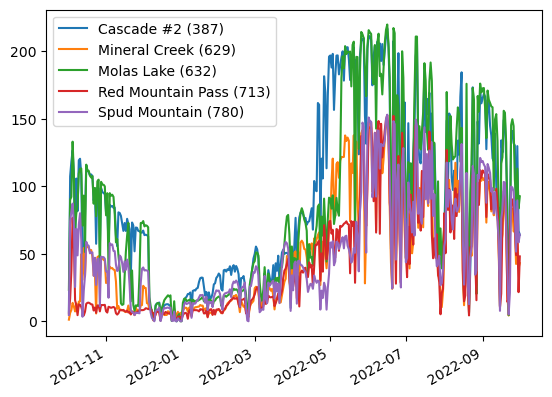

In [15]:
# compute daily net LW from net SW and net radiation
# net radiation is daily ouput (average all-wave), net SW is hourly
# --> convert all to mean daily and add this to the em_df
daily_net_solar = df['animas_unified_net_solar'].resample('D').mean()

# Set the index to match the em_df index (which is daily but timestamped at 23:00)
daily_net_solar.index = em_df.index

# Plot it
daily_net_solar.plot()

In [16]:
# Add these mean daily net solar values to the big em_df using the site-level column index to align them
for site in em_df.columns.get_level_values(0).unique():
    em_df.loc[:, (site, 'net_solar')] = daily_net_solar.loc[:, site]

In [17]:
# Summarize to weekly averages again
weekly_avg = em_df.resample('W').mean()
weekly_avg.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53 entries, 2021-10-03 to 2022-10-02
Freq: W-SUN
Data columns (total 55 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   (Cascade #2 (387), SWI)                     53 non-null     float64
 1   (Cascade #2 (387), cold_content)            53 non-null     float64
 2   (Cascade #2 (387), evaporation)             53 non-null     float64
 3   (Cascade #2 (387), latent_heat)             53 non-null     float64
 4   (Cascade #2 (387), net_rad)                 53 non-null     float64
 5   (Cascade #2 (387), precip_advected)         53 non-null     float64
 6   (Cascade #2 (387), sensible_heat)           53 non-null     float64
 7   (Cascade #2 (387), snow_soil)               53 non-null     float64
 8   (Cascade #2 (387), snowmelt)                53 non-null     float64
 9   (Cascade #2 (387), sum_EB)                  53 non-null  

(np.float64(18901.0), np.float64(19144.0))

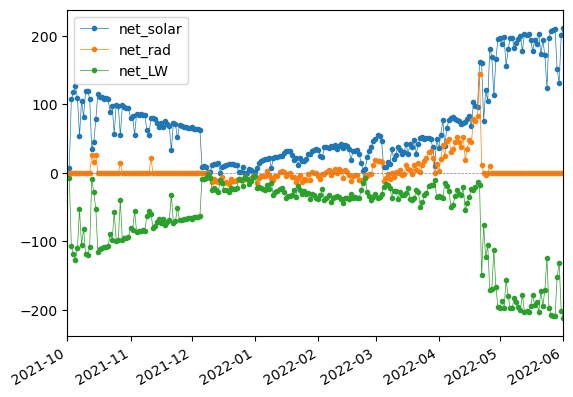

In [18]:
radiations_df = em_df[this_site][['net_solar', 'net_rad']]
# Plot the diff between net_rad and net_solar to see the net LW contribution
radiations_df['net_LW'] = (radiations_df.loc[:, 'net_rad'] - radiations_df.loc[:, 'net_solar'])
# # Compute total absolute radiation flux
# radiations_df['total_flux'] = np.abs(radiations_df.loc[:, 'net_solar']) + np.abs(radiations_df.loc[:, 'net_LW'])
radiations_df.plot(marker='.', linewidth=0.5)
# add a horizontal zero line
plt.axhline(0, color='grey', linewidth=0.5, linestyle='--')
# Shorten the xlims to the most interesting part of the season, Oct to May
plt.xlim('2021-10-01', '2022-06-01')

In [19]:
# # Compute net solar proportion of total flux
# radiations_df.loc[:, 'net_solar_prop'] = np.abs(radiations_df.loc[:, 'net_solar']) / radiations_df.loc[:, 'total_flux']
# # Do the same for net LW
# radiations_df.loc[:, 'net_LW_prop'] = np.abs(radiations_df.loc[:, 'net_LW']) / radiations_df.loc[:, 'total_flux']
# # Plot
# radiations_df.loc[:, 'net_solar_prop'].plot(marker='.', linewidth=0.5, figsize=(12, 6))
# radiations_df.loc[:, 'net_LW_prop'].plot(marker='.', linewidth=0.5)
# plt.legend()

In [20]:
# # Plot proportions of weekly average as a stacked bar plot
# prop_cols = ['net_solar_prop', 'net_LW_prop']
# radiations_df[prop_cols].resample('W').mean().plot(kind='bar', stacked=True, figsize=(15, 2))
# # Reformat xtick labels to show month and day
# xticks = radiations_df.resample('W').mean().index
# xtick_labels = [xtick.strftime('%b %d') for xtick in xticks]
# plt.xticks(ticks=range(len(xticks)), labels=xtick_labels);
# # Add a horizontal line at y=0.5 to show the 50% contribution level
# plt.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
# plt.legend(bbox_to_anchor=(0.5, 1.2), loc='center')
# # Trim to the most interesting part of the season in week numbers, Oct to May
# plt.xlim(-1, week_end + 0.5)

In [21]:
# # Multiply daily proportion of net solar to net radiation
# # to get the overall contribution to total absolute energy balance
# abs_df['total_abs_flux'] = abs_df.sum(axis=1)
# abs_df['net_solar'] = radiations_df.loc[:, 'net_solar_prop'] * abs_df.loc[:, 'net_rad']
# # Do the same for net LW
# abs_df['net_LW'] = radiations_df.loc[:, 'net_LW_prop'] * abs_df.loc[:, 'net_rad']

# # Then move to daily plotting of time periods
# flux_cols = ['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_solar', 'net_LW']
# for col in flux_cols:
#     abs_df[f'{col}_pct'] = abs_df[col] / abs_df['total_abs_flux'] * 100

# ax = abs_df.plot(y=flux_cols, kind='bar', stacked=True, figsize=(12, 6), legend=False)

# # Reformat xtick labels to show month and day for only the first of each month
# xticks = abs_df.index
# xtick_labels = [xtick.strftime('%b %d') if xtick.day == 1 else '' for xtick in xticks]
# plt.xticks(ticks=range(len(xticks)), labels=xtick_labels);
# plt.ylabel('Absolute Energy Flux (W/m^2)')
# # Trim to the most interesting part of the season in day numbers, Oct to May
# plt.xlim(-1, week_end * 7)
# plt.legend()

### Now that you have the seasonal view, lets chop up time periods further by:
 - accumulation/ablation
 - actual interesting events (processes, cold snaps, melt events)

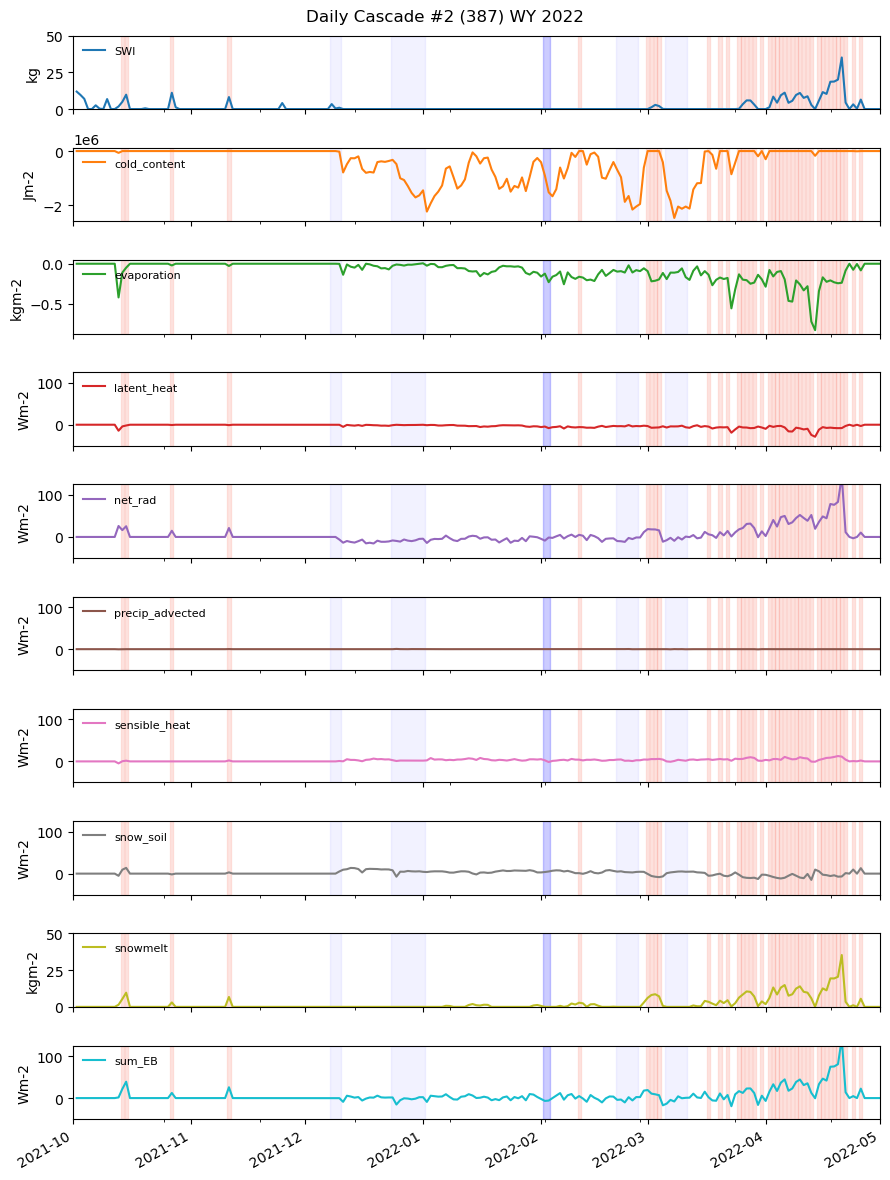

In [22]:
# Plot all the variables
fig = sub_df.plot(subplots=True, figsize=(9, 12), legend=False)
for idx, ax in enumerate(fig):
    varname = sub_df.columns[idx]

    # Make sure the legend for each subplot is inside the plot with a white background
    ax.legend([varname], loc='upper left', frameon=False, facecolor='white', edgecolor='none', fontsize=8)
    # Modify y-axis limits
    # SWI and snowmelt should share ylims
    if varname == 'SWI' or varname == 'snowmelt':
        ax.set_ylim(0, 50)
    # Otherwise, as long as the variable is not cold_content or evaporation
    # Set the ylims for shared energy flux scales
    elif varname != 'cold_content' and varname != 'evaporation':
        ax.set_ylim(-50, 125)
        ax.set_ylabel('Wm-2')

    # Add ylabels for the other variables
    if varname == 'cold_content':
        ax.set_ylabel('Jm-2')
    elif varname == 'evaporation' or varname == 'snowmelt':
        ax.set_ylabel('kgm-2')
    elif varname == 'SWI':
        ax.set_ylabel('kg')

# Shorten the xlims to the most interesting part of the season
plt.xlim('2021-10-01', '2022-05-01')

# Ok, check out the SNOTEL sites for some context (tmax, tmin, snow depth)
# Identified the following interesting dates for Animas in WY2022
# snow accumulation and freezing temps: 12.8–12.10, 12.24.21–1.1.22, 2.21–2.26.22, 3.6-3.11.22
# cold snap 2.2–2.3.22

# Deal with shading
# Determine the dates where sum_EB > 0
sum_EB = sub_df['sum_EB']
sum_EB_dates = sum_EB[sum_EB > 0].index

# Determine dates where cold_content == 0
cold_content = sub_df['cold_content']
cold_content_zero_dates = cold_content[cold_content == 0].index

# Determine the intersection of those two sets of dates
both_conditions_dates = sum_EB_dates.intersection(cold_content_zero_dates)

# Add vertical rectangles to the plots at those dates
delta_hr = 10
for ax in plt.gcf().axes:
    for date in both_conditions_dates:
        ax.axvspan(date - pd.Timedelta(hours=delta_hr), date + pd.Timedelta(hours=delta_hr), color='salmon', alpha=0.2)

# Ok, now add in some coloring to show the different periods of interest
# snow accumulation and freezing temps: 12.8–12.10, 12.24.21–1.1.22, 2.21–2.26.22, 3.6-3.11.22
tmax_freezing_periods = [('2021-12-08', '2021-12-10'), ('2021-12-24', '2022-01-01'), ('2022-02-21', '2022-02-26'), ('2022-03-06', '2022-03-11')]
# cold snap 2.2–2.3.22
cold_snap_period = ('2022-02-02', '2022-02-03')
# Add vertical rectangles to the plots at those dates
for ax in plt.gcf().axes:
    for start, end in tmax_freezing_periods:
        ax.axvspan(pd.to_datetime(start) - pd.Timedelta(hours=delta_hr), pd.to_datetime(end) + pd.Timedelta(hours=delta_hr), color='blue', alpha=0.05)
    ax.axvspan(pd.to_datetime(cold_snap_period[0]) - pd.Timedelta(hours=delta_hr), pd.to_datetime(cold_snap_period[1]) + pd.Timedelta(hours=delta_hr), color='blue', alpha=0.2)

plt.suptitle(f'Daily {this_site} WY {WY}', fontsize=12);
plt.tight_layout()

In [23]:
# # Plot all the variables
# fig = abs_df.plot(subplots=True, figsize=(9, 12), legend=False)
# for idx, ax in enumerate(fig):
#     varname = abs_df.columns[idx]

#     # Make sure the legend for each subplot is inside the plot with a white background
#     ax.legend([varname], loc='upper left', frameon=False, facecolor='white', edgecolor='none', fontsize=8)

#     # Modify y-axis limits based on varname
#     if varname[:-4] == '_pct':
#         ax.set_ylim(0, 100)
#         ax.set_ylabel('Percent Contribution (%)')
#     else:
#         ax.set_ylim(-50, 125)
#         ax.set_ylabel('Wm-2')

# # Shorten the xlims to the most interesting part of the season
# plt.xlim('2021-10-01', '2022-05-01')

# # Ok, check out the SNOTEL sites for some context (tmax, tmin, snow depth)
# # Identified the following interesting dates for Animas in WY2022
# # snow accumulation and freezing temps: 12.8–12.10, 12.24.21–1.1.22, 2.21–2.26.22, 3.6-3.11.22
# # cold snap 2.2–2.3.22

# # Deal with shading using determinations from previous cell
# # Determine the dates where sum_EB > 0
# # Determine dates where cold_content == 0
# # Determine the intersection of those two sets of dates
# # Add vertical rectangles to the plots at those dates
# delta_hr = 10
# for ax in plt.gcf().axes:
#     for date in both_conditions_dates:
#         ax.axvspan(date - pd.Timedelta(hours=delta_hr), date + pd.Timedelta(hours=delta_hr), color='salmon', alpha=0.2)

# # Ok, now add in some coloring to show the different periods of interest
# # snow accumulation and freezing temps: 12.8–12.10, 12.24.21–1.1.22, 2.21–2.26.22, 3.6-3.11.22
# tmax_freezing_periods = [('2021-12-08', '2021-12-10'), ('2021-12-24', '2022-01-01'), ('2022-02-21', '2022-02-26'), ('2022-03-06', '2022-03-11')]
# # cold snap 2.2–2.3.22
# cold_snap_period = ('2022-02-02', '2022-02-03')
# # Add vertical rectangles to the plots at those dates
# for ax in plt.gcf().axes:
#     for start, end in tmax_freezing_periods:
#         ax.axvspan(pd.to_datetime(start) - pd.Timedelta(hours=delta_hr), pd.to_datetime(end) + pd.Timedelta(hours=delta_hr), color='blue', alpha=0.05)
#     ax.axvspan(pd.to_datetime(cold_snap_period[0]) - pd.Timedelta(hours=delta_hr), pd.to_datetime(cold_snap_period[1]) + pd.Timedelta(hours=delta_hr), color='blue', alpha=0.2)

# plt.suptitle(f'Daily {this_site} WY {WY}', fontsize=12);
# plt.tight_layout()

In [24]:
# group values for each variable by cold_snap_period, tmax_freezing_periods, both_conditions_dates
# and the rest of the season to compare the distributions of energy fluxes in these different conditions
# and plot boxplots of each variable in those different conditions
conditions = {
    'cold_snap': (sub_df.index >= pd.to_datetime(cold_snap_period[0])) & (sub_df.index <= pd.to_datetime(cold_snap_period[1])),
    'tmax_freezing': np.zeros(len(sub_df), dtype=bool),
    'melt': np.zeros(len(sub_df), dtype=bool)
}
for start, end in tmax_freezing_periods:
    conditions['tmax_freezing'] |= (sub_df.index >= pd.to_datetime(start)) & (sub_df.index <= pd.to_datetime(end))
    conditions['melt'] = sub_df.index.isin(both_conditions_dates)

# The rest of the season is when none of these conditions are met
conditions['rest_of_season'] = ~(conditions['cold_snap'] | conditions['tmax_freezing'] | conditions['melt'])

In [25]:
# Add condition column to the sub_df for plotting based on the collapsed conditions dict
sub_df['condition'] = 'rest_of_season'
for cond in conditions:
    sub_df.loc[conditions[cond], 'condition'] = cond
sub_df.head()

,SWI,cold_content,evaporation,latent_heat,net_rad,precip_advected,sensible_heat,snow_soil,snowmelt,sum_EB,condition
2021-10-01 23:00:00,11.872620,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,rest_of_season
2021-10-02 23:00:00,9.591003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,rest_of_season
2021-10-03 23:00:00,6.958191,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,rest_of_season
2021-10-04 23:00:00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,rest_of_season
2021-10-05 23:00:00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,rest_of_season


In [26]:
# # Add condition column to the abs_df for plotting based on the collapsed conditions dict
# abs_df['condition'] = 'rest_of_season'
# for cond in conditions:
#     abs_df.loc[conditions[cond], 'condition'] = cond
# abs_df.head()

In [27]:
# Add radiation vals into the sub_df for plotting
sub_df['net_solar'] = radiations_df.loc[:, 'net_solar']
sub_df['net_LW'] = radiations_df.loc[:, 'net_LW']

full_eb_cols = ['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_solar', 'net_LW']
flux_cols = ['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_rad']

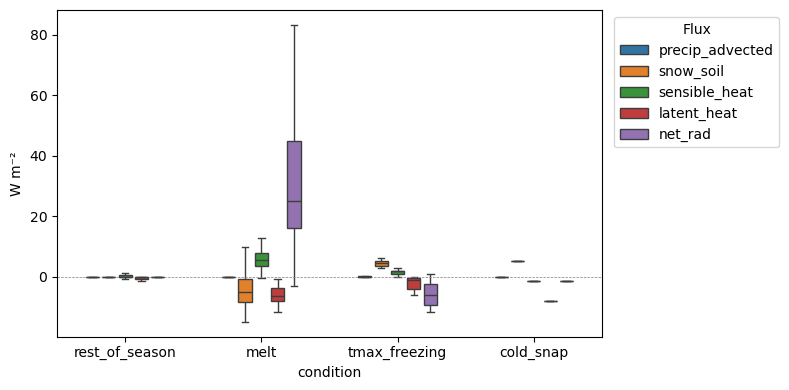

In [28]:
# For plotting the way I want it, create a new df that drops the date index
# compress flux_cols into a single column with types
# Assign a single condition label per date (priority: both > cold_snap > tmax_freezing > rest)
condition_labels = pd.Series('rest_of_season', index=sub_df.index)
for cond in ['tmax_freezing', 'cold_snap', 'melt']:
    condition_labels[conditions[cond]] = cond

melted = sub_df[flux_cols].copy()
melted['condition'] = condition_labels
melted = melted.melt(id_vars='condition', value_vars=flux_cols, var_name='flux', value_name='value')
melted.head()
fig, ax = plt.subplots(figsize=(8, 4))
# Add a little more padding between the boxes new gap parameter in seaborn ≥0.13!
sns.boxplot(data=melted, x='condition', y='value', hue='flux', ax=ax, width=0.6, gap=0.2, showfliers=False)
ax.set_ylabel('W m⁻²')
ax.legend(title='Flux', bbox_to_anchor=(1.01, 1), loc='upper left')
# Add horizontal line at y=0
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()

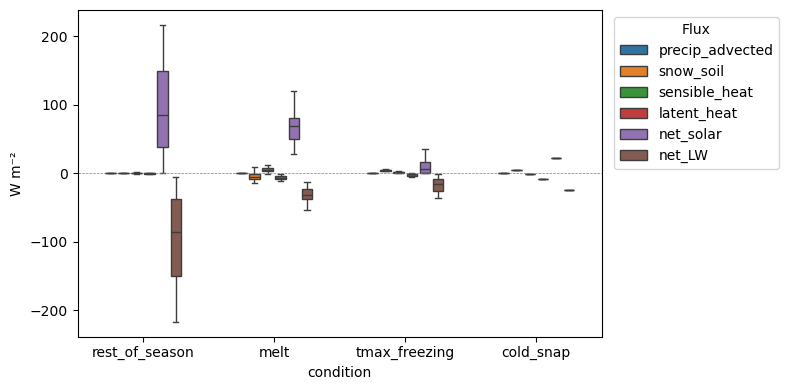

In [29]:
# For plotting the way I want it, create a new df that drops the date index
# compress flux_cols into a single column with types
# Assign a single condition label per date (priority: both > cold_snap > tmax_freezing > rest)
condition_labels = pd.Series('rest_of_season', index=sub_df.index)
for cond in ['tmax_freezing', 'cold_snap', 'melt']:
    condition_labels[conditions[cond]] = cond

melted = sub_df[full_eb_cols].copy()
melted['condition'] = condition_labels
melted = melted.melt(id_vars='condition', value_vars=full_eb_cols, var_name='flux', value_name='value')
melted.head()
fig, ax = plt.subplots(figsize=(8, 4))
# Add a little more padding between the boxes new gap parameter in seaborn ≥0.13!
sns.boxplot(data=melted, x='condition', y='value', hue='flux', ax=ax, width=0.6, gap=0.2, showfliers=False)
ax.set_ylabel('W m⁻²')
ax.legend(title='Flux', bbox_to_anchor=(1.01, 1), loc='upper left')
# Add horizontal line at y=0
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()

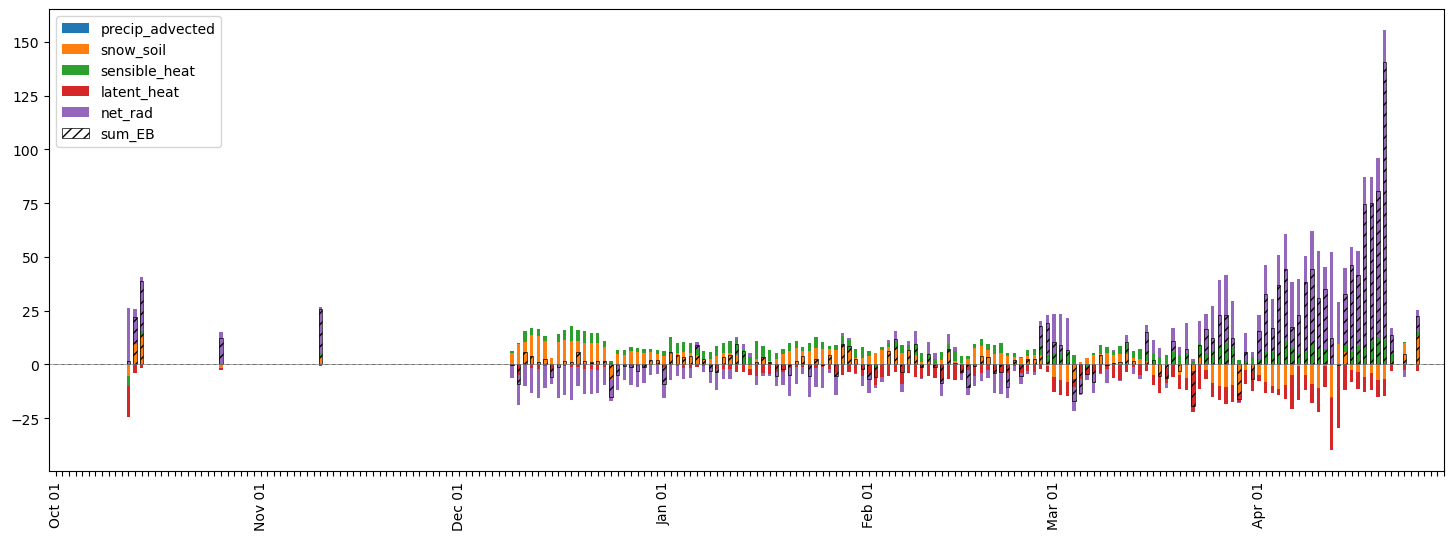

In [30]:
# Using sub_df with all the radiation, replot the stacked bar_plot
# Plot this buddy as a stacked bar plot
ax = sub_df.plot(y=flux_cols,
                kind='bar', stacked=True, figsize=(18, 6), legend=False)
# Plot sum_EB as a line on top of the stacked bar plot as a hatch-filled bar
sub_df.plot(y='sum_EB', kind='bar', ax=ax, hatch='///', color='none', edgecolor='black', linewidth=0.5, label='sum_EB', legend=True)

ax.axhline(0, color='grey', linewidth=0.5, linestyle='-')
# Format xtick labels to show month and day
xticks = sub_df.index
# Mon abbreviation and day number
xtick_labels = [xtick.strftime('%b %d') if xtick.day == 1 else '' for xtick in xticks]
ax.set_xticks(ticks=range(len(xticks)), labels=xtick_labels)
# Shorten the xlims to the most interesting part of the season, Oct to June, in days
ax.set_xlim(-1, 210)
plt.legend()

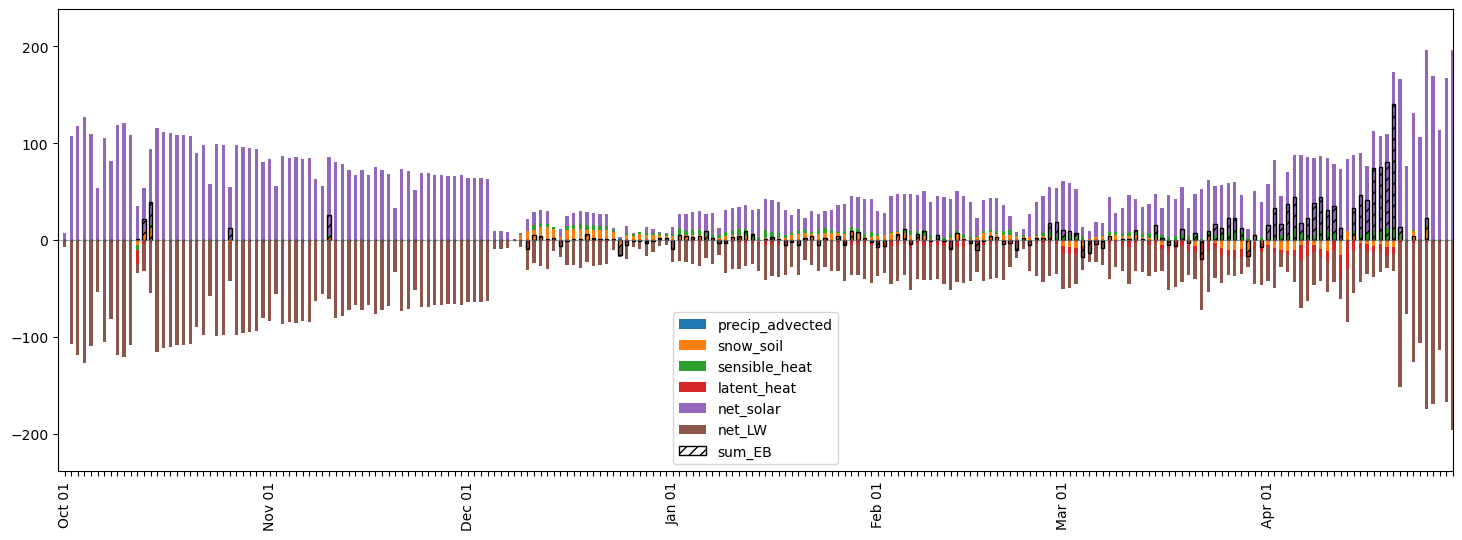

In [31]:
# Using sub_df with all the radiation, replot the stacked bar_plot
# Plot this buddy as a stacked bar plot
ax = sub_df.plot(y=full_eb_cols,
                kind='bar', stacked=True, figsize=(18, 6), legend=False)
# Plot sum_EB as a line on top of the stacked bar plot as a hatch-filled bar
sub_df.plot(y='sum_EB', kind='bar', ax=ax, hatch='///', color='none', edgecolor='black', linewidth=1, label='sum_EB', legend=True)

ax.axhline(0, color='grey', linewidth=0.5, linestyle='-')
# Format xtick labels to show month and day
xticks = sub_df.index
# Mon abbreviation and day number
xtick_labels = [xtick.strftime('%b %d') if xtick.day == 1 else '' for xtick in xticks]
ax.set_xticks(ticks=range(len(xticks)), labels=xtick_labels)
# Shorten the xlims to the most interesting part of the season, Oct to June, in days
ax.set_xlim(-1, 210)
plt.legend()

In [32]:
# # Using sub_df with all the radiation, replot the stacked bar_plot this is a radiation check
# # Plot this buddy as a stacked bar plot
# ax = radiations_df.plot(y=['net_solar', 'net_LW'],
#                 kind='bar', stacked=True, figsize=(18, 6), legend=False)
# # Plot sum_EB as a line on top of the stacked bar plot as a hatch-filled bar
# sub_df.plot(y='net_rad', kind='bar', ax=ax, hatch='///', color='none', edgecolor='black', linewidth=0.5, label='net_rad', legend=True)

# ax.axhline(0, color='grey', linewidth=0.5, linestyle='-')
# # Format xtick labels to show month and day
# xticks = sub_df.index
# # Mon abbreviation and day number
# xtick_labels = [xtick.strftime('%b %d') if xtick.day == 1 else '' for xtick in xticks]
# ax.set_xticks(ticks=range(len(xticks)), labels=xtick_labels)
# # Shorten the xlims to the most interesting part of the season, Oct to June, in days
# ax.set_xlim(-1, 250)
# plt.legend()

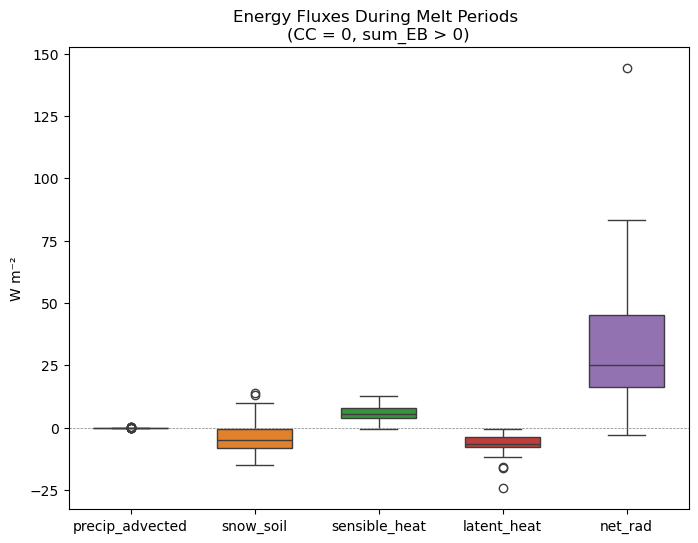

In [33]:
# Identify days where snowpack is melting --> this is both_conditions_dates from before
# Do not use snowmelt to threshold as this value can be positive when cold content is not zero
melt_df = sub_df.loc[both_conditions_dates]
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(melt_df[flux_cols], width=0.6)
ax.set_ylabel('W m⁻²')
ax.set_title('Energy Fluxes During Melt Periods \n(CC = 0, sum_EB > 0)')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')

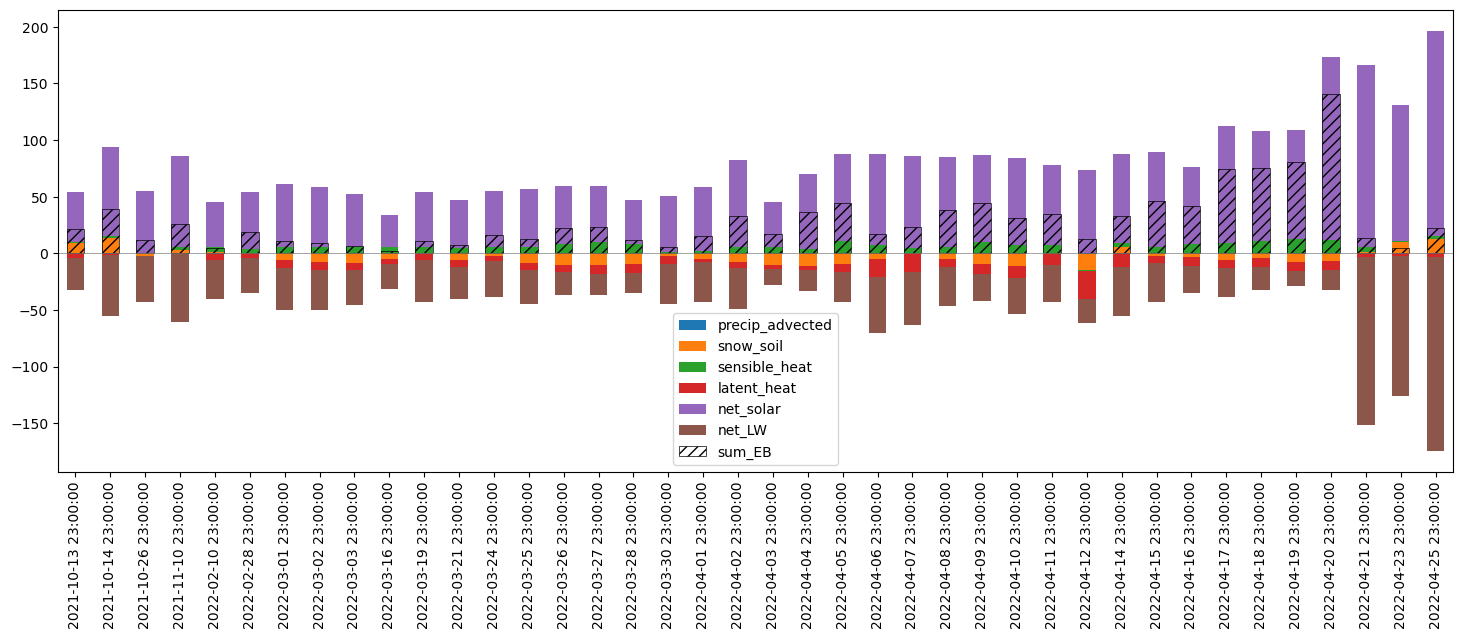

In [34]:
# Plot the proportional contribution of each flux during the melt periods as a stacked bar plot
ax = melt_df.plot(y=['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_solar', 'net_LW'],
                kind='bar', stacked=True, figsize=(18, 6), legend=False)
# Plot sum_EB as a line on top of the stacked bar plot as a hatch-filled bar
melt_df.plot(y='sum_EB', kind='bar', ax=ax, hatch='///', color='none', edgecolor='black', linewidth=0.5, label='sum_EB', legend=True)
# # Compute sum of positive energy fluxes
# melt_df[['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_solar', 'net_LW']].clip(lower=0).sum(axis=1)

ax.axhline(0, color='grey', linewidth=0.5, linestyle='-')
plt.legend()

In [35]:
# Ok, not for these time periods only, compute the proportional contribution of only the positive fluxes
# create a new df and set the negative fluxes as 0, we will not count them for this contribution analysis
full_eb_cols = ['precip_advected', 'snow_soil', 'sensible_heat', 'latent_heat', 'net_solar', 'net_LW']
melt_energy_contributions = melt_df[full_eb_cols].clip(lower=0).copy()
melt_energy_contributions.info()

# Sum up all the positive fluxes
melt_energy_contributions['total_positive_flux'] = melt_energy_contributions.sum(axis=1)

# Compute the proportional contribution of each flux to the total positive energy flux
for col in full_eb_cols:
    melt_energy_contributions[f'{col}_pct'] = melt_energy_contributions[col] / melt_energy_contributions['total_positive_flux'] * 100

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 40 entries, 2021-10-13 23:00:00 to 2022-04-25 23:00:00
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   precip_advected  40 non-null     float64
 1   snow_soil        40 non-null     float64
 2   sensible_heat    40 non-null     float64
 3   latent_heat      40 non-null     float64
 4   net_solar        40 non-null     float64
 5   net_LW           40 non-null     float64
dtypes: float64(6)
memory usage: 2.2 KB


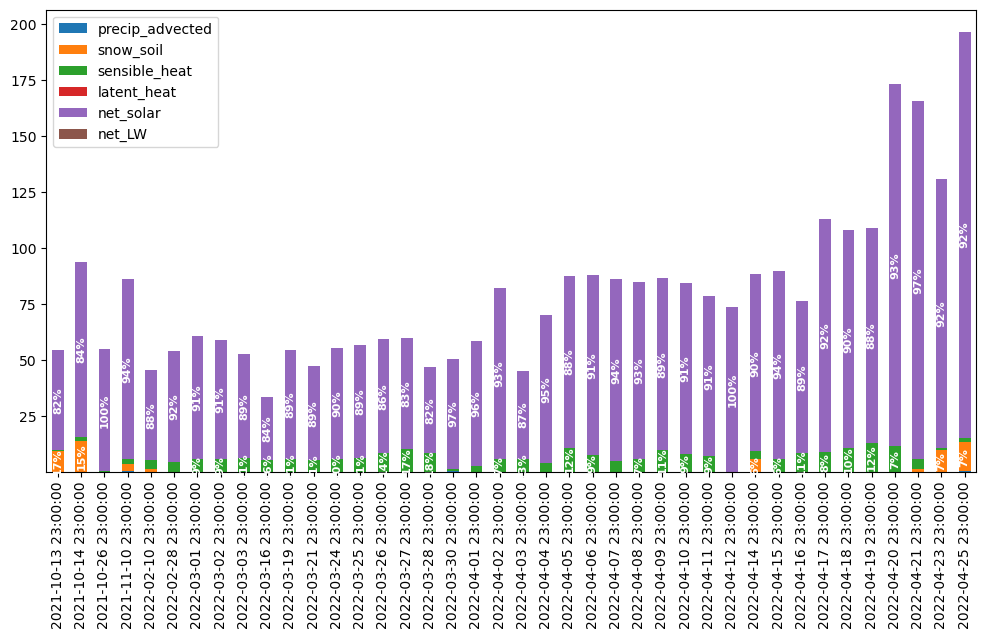

In [ ]:
# Now plot these contributions as a stacked bar plot
ax = melt_energy_contributions.plot(y=full_eb_cols, kind='bar', stacked=True, figsize=(12, 6), legend=False)
ax.set_ylabel('Positive Flux Melt Contributions (W m⁻²)')
# Annotate each stacked segment with its percent contribution
for bar_idx, dt in enumerate(melt_energy_contributions.index):
    row_vals = melt_energy_contributions.loc[dt]
    row_cumulativesum = row_vals[full_eb_cols].cumsum()

    for col in full_eb_cols:
        value = row_vals[col]
        pct = row_vals[f'{col}_pct']

        # Only annotate segments large enough to read
        if value > 5:
            xloc = bar_idx
            yloc = row_cumulativesum[col] - value / 2.0
            ax.text(xloc, yloc, f'{pct:.0f}%',
                    ha='center', va='center',
                    fontsize=8, rotation=90,
                    fontweight='bold', color='white')
# Reformat xtick labels to show month and day
xticks = melt_energy_contributions.index
xtick_labels = [xtick.strftime('%b %d') for xtick in xticks]
plt.xticks(ticks=range(len(xticks)), labels=xtick_labels)
plt.legend(bbox_to_anchor=(1.01, 1), title='Positive Flux Melt Contributions');

# Compute albedo melt contributions

First step, compute net solar contribution to melt:  

We will use daily snowmelt values to attribute the fraction of melt to each energy balance component.  
For example, the proportion of snowmelt attributable to albedo, via net solar radiation, compared to overall melt energy is: **`snowmelt * SWnet / ∆Q`**
  
Multiply snowmelt with the generated partitioned energy fractions from above to compute melt contributions

Second step is to 

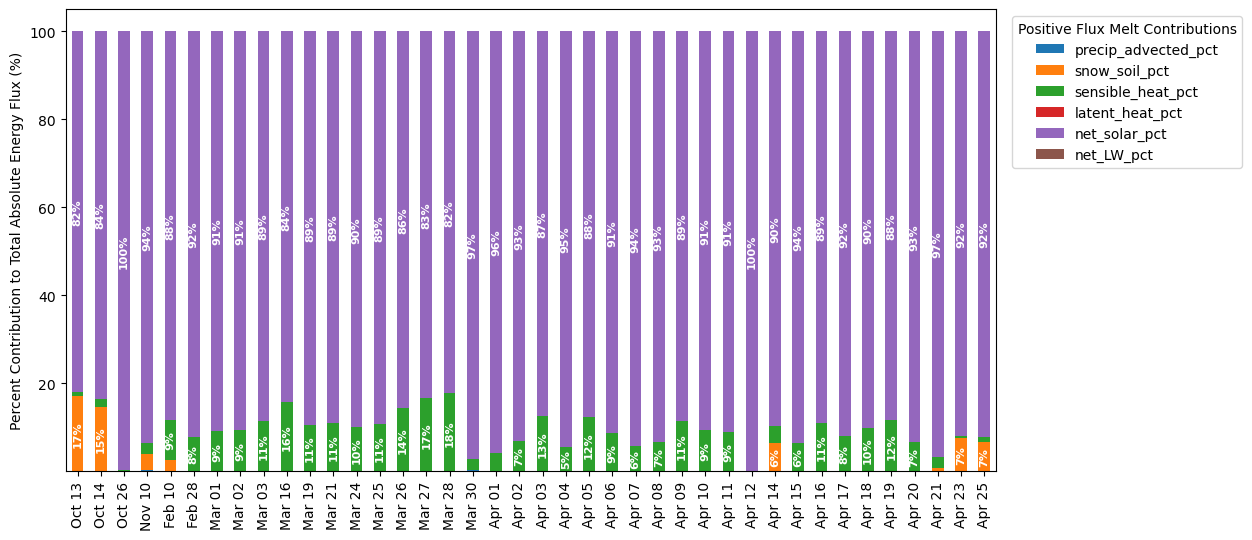

In [ ]:
# Plot only the pct contributions in melt_energy_contributions
pct_cols = [col for col in melt_energy_contributions.columns if col.endswith('_pct')]
ax = melt_energy_contributions.plot(y=pct_cols, kind='bar', stacked=True, figsize=(12, 6), legend=False)
ax.set_ylabel('Percent Contribution to Positive Flux (%)')
# Annotate each stacked segment with its percent contribution
for bar_idx, dt in enumerate(melt_energy_contributions.index):
    row_vals = melt_energy_contributions.loc[dt]
    row_cumulativesum = row_vals[pct_cols].cumsum()

    for col in pct_cols:
        value = row_vals[col]

        # Only annotate segments large enough to read
        if value > 5:
            xloc = bar_idx
            yloc = row_cumulativesum[col] - value / 2.0
            ax.text(xloc, yloc, f'{value:.0f}%',
                    ha='center', va='center',
                    fontsize=8, rotation=90,
                    fontweight='bold', color='white')
# Reformat xtick labels to show month and day
xticks = melt_energy_contributions.index
xtick_labels = [xtick.strftime('%b %d') for xtick in xticks]
plt.xticks(ticks=range(len(xticks)), labels=xtick_labels)
plt.legend(bbox_to_anchor=(1.01, 1), title='Positive Flux Melt Contributions');

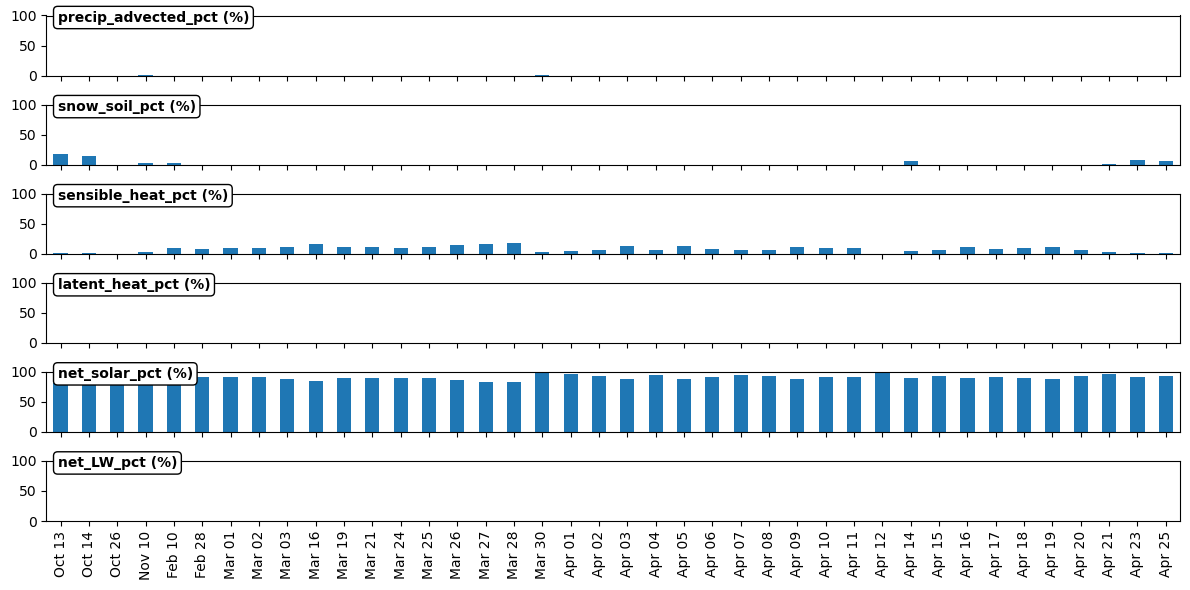

In [38]:
# Plot this in subplots for each pct_col
fig, axes = plt.subplots(len(pct_cols), 1, figsize=(12, len(pct_cols)), sharex=True, sharey=True)
for idx, col in enumerate(pct_cols):
    melt_energy_contributions.plot(y=col, kind='bar', ax=axes[idx], legend=False)
    ax = axes[idx]
    ax.annotate(f'{col} (%)', xy=(0.01, 0.9), xycoords='axes fraction',
                       fontsize=10, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='white', edgecolor='black')
                       )
# Reformat xtick labels to show month and day for only the first of each month
# Reformat xtick labels to show month and day
xticks = melt_energy_contributions.index
xtick_labels = [xtick.strftime('%b %d') for xtick in xticks]
ax.set_xticks(ticks=range(len(xticks)), labels=xtick_labels)
ax.set_ylim(0, 100)
plt.tight_layout()

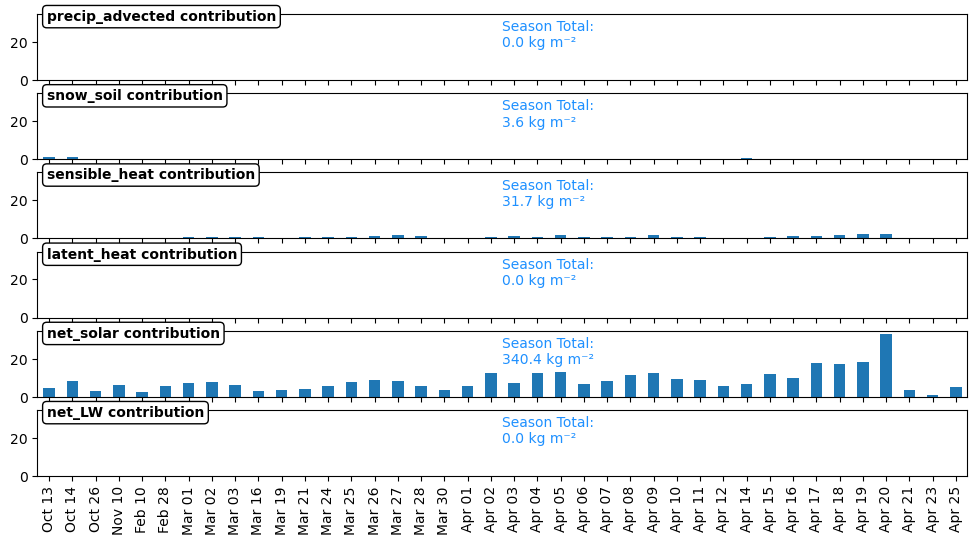

In [39]:
# Calculate the melt contributions of each percent term by multiplying with snowmelt
# TODO check out code for snowmelt
for col in pct_cols:
    melt_energy_contributions[f'{col}_melt_contribution'] = melt_energy_contributions[col] / 100 * sub_df['snowmelt']

# Plot these melt contributions in subplots
melt_contrib_cols = [col for col in melt_energy_contributions.columns if col.endswith('_melt_contribution')]
fig, axes = plt.subplots(len(melt_contrib_cols), 1, figsize=(12, len(melt_contrib_cols)), sharex=True, sharey=True)
for idx, col in enumerate(melt_contrib_cols):
    melt_energy_contributions.plot(y=col, kind='bar', ax=axes[idx], legend=False)
    ax = axes[idx]
    ax.annotate(f'{col.split("_pct_")[0]} contribution', xy=(0.01, 0.9), xycoords='axes fraction',
                       fontsize=10, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='white', edgecolor='black')
                       )
    # Calculate and annotate cumulative seasonal melt contribution for each flux
    cumulative_melt = melt_energy_contributions[col].sum()
    ax.annotate(f'Season Total:\n{cumulative_melt:.1f} kg m⁻²', xy=(0.5, 0.5), xycoords='axes fraction',
                        fontsize=10, color='dodgerblue')

    # Reformat xtick labels to show month and day for only the first of each month
    xticks = melt_energy_contributions.index
    xtick_labels = [xtick.strftime('%b %d') for xtick in xticks]
    ax.set_xticks(ticks=range(len(xticks)), labels=xtick_labels)

In [40]:
# What's the cumulative snowmelt?
sub_df['snowmelt'].sum()

np.float64(421.75964510200004)

In [41]:
# What's the cumulative SWI?
sub_df['SWI'].sum()

np.float64(579.8187888165301)

In [42]:
# Once this is complete for one site, turn this into a nice script
# And run for all SNOTEL sites, for all time periods and basins